In [1]:
!pip3 install mndino
!pip install 'huggingface_hub[cli,torch]'

  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached scipy-1.16.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached imageio-2.37.2-py3-none-any.whl.metadata (9.7 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3

# Run pre-trained model to predict micronuclei

In [1]:
from huggingface_hub import hf_hub_download
import skimage
import torch
from mndino import mnmodel, evaluation

# plotting
import matplotlib.pyplot as plt

- download pre-trained model

In [2]:
REPO_ID = "CaicedoLab/mnDINO"
FILENAME = "mnDINO_v1.pth"
model_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

mnDINO_v1.pth:   0%|          | 0.00/174M [00:00<?, ?B/s]

- load pre-trained model

In [4]:
gpu = 0
device = f"cuda:{gpu}" if torch.cuda.is_available() else 'cpu'
model = mnmodel.MicronucleiModel(device=device)

In [5]:
model.load(model_path)

Using cache found in /home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main
/home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


- make predictions

In [6]:
import numpy as np

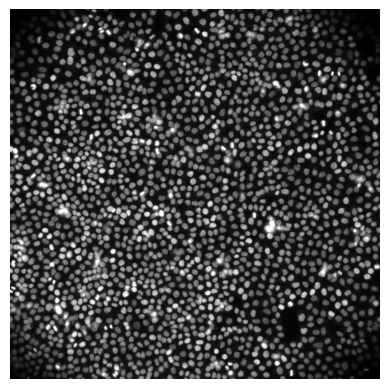

In [8]:
im_path = '/scr/data/annotated_mn_datasets/test/images/20X_c0-DAPI_A1_Tile-130.tif'
im = skimage.io.imread(im_path)

plt.imshow(im, cmap='gray')
plt.axis('off')
plt.show()

In [9]:
STEP = 32 # recommended value
PREDICTION_BATCH = 4
THRESHOLD = 0.5

im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32") # normalize image
probabilities = model.predict(im, stride=1, step=STEP, batch_size=PREDICTION_BATCH)

mn_predictions = probabilities[0,:,:] > THRESHOLD
nuclei_predictions = probabilities[1,:,:] > THRESHOLD

/scr/yren/miniconda3/envs/test-mndino/lib/python3.12/site-packages/mndino/mnmodel.py:341: RuntimeWarning: invalid value encountered in divide
  probabilities = probabilities/counts


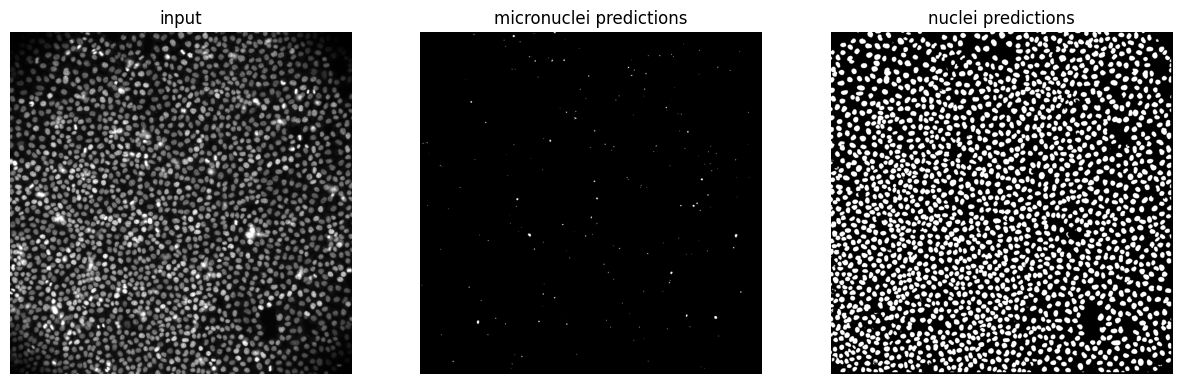

In [10]:
fig, ax = plt.subplots(1,3, figsize=(15,15))

img_lst = [im, mn_predictions, nuclei_predictions]
titles = ['input', 'micronuclei predictions', 'nuclei predictions']
for i in range(3):
    ax[i].imshow(img_lst[i], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(titles[i])

# Evaluation (assume you have annotated micronuclei ground truth)

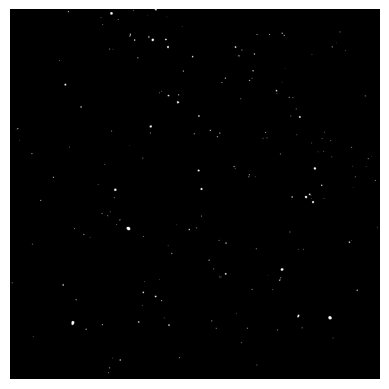

In [13]:
gt_path = '/scr/data/annotated_mn_datasets/test/mn_masks/20X_c0-DAPI_A1_Tile-130.png'
mn_gt = skimage.io.imread(gt_path)
plt.imshow(mn_gt > 0, cmap='gray')
plt.axis('off')
plt.show()

In [14]:
imid = '20X_c0-DAPI_A1_Tile-130'
precision, recall = evaluation.segmentation_report(predictions=mn_predictions, gt=mn_gt, intersection_ratio=0.1, wandb_mode=False)
print(f'{imid}, Precision: {precision}, Recall: {recall}')

20X_c0-DAPI_A1_Tile-130, Precision: 0.8137254901960784, Recall: 0.8877005347593583
